In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
def simulate_trajectory(kappa, x0, y0, theta0, velocities, dt=1):
    recon_x = [x0]
    recon_y = [y0]
    theta = theta0
    for v in velocities:
        theta += -kappa * v * dt
        new_x = recon_x[-1] + v * np.cos(theta) * dt
        new_y = recon_y[-1] + v * np.sin(theta) * dt
        recon_x.append(new_x)
        recon_y.append(new_y)
    return np.array(recon_x), np.array(recon_y)

def compute_mse(x1, y1, x2, y2):
    min_len = min(len(x1), len(x2))
    return np.mean((x1[:min_len] - x2[:min_len])**2 + (y1[:min_len] - y2[:min_len])**2)

def process_trajectory(file_path):
    df = pd.read_csv(file_path).dropna(subset=["velocity_px"]).reset_index(drop=True)
    x = df["x"].values
    y = df["y"].values
    v_framewise = df["velocity_px"].values
    dx0 = x[1] - x[0]
    dy0 = y[1] - y[0]
    initial_theta = np.arctan2(dy0, dx0)

    k_range = np.linspace(-0.05, 0.05, 500)
    best_kappa = None
    best_mse = float("inf")
    best_recon = (None, None)

    for kappa in k_range:
        rx, ry = simulate_trajectory(kappa, x[0], y[0], initial_theta, v_framewise)
        error = compute_mse(x, y, rx, ry)
        if error < best_mse:
            best_mse = error
            best_kappa = kappa
            best_recon = (rx, ry)

    return x, y, best_recon[0], best_recon[1], best_kappa

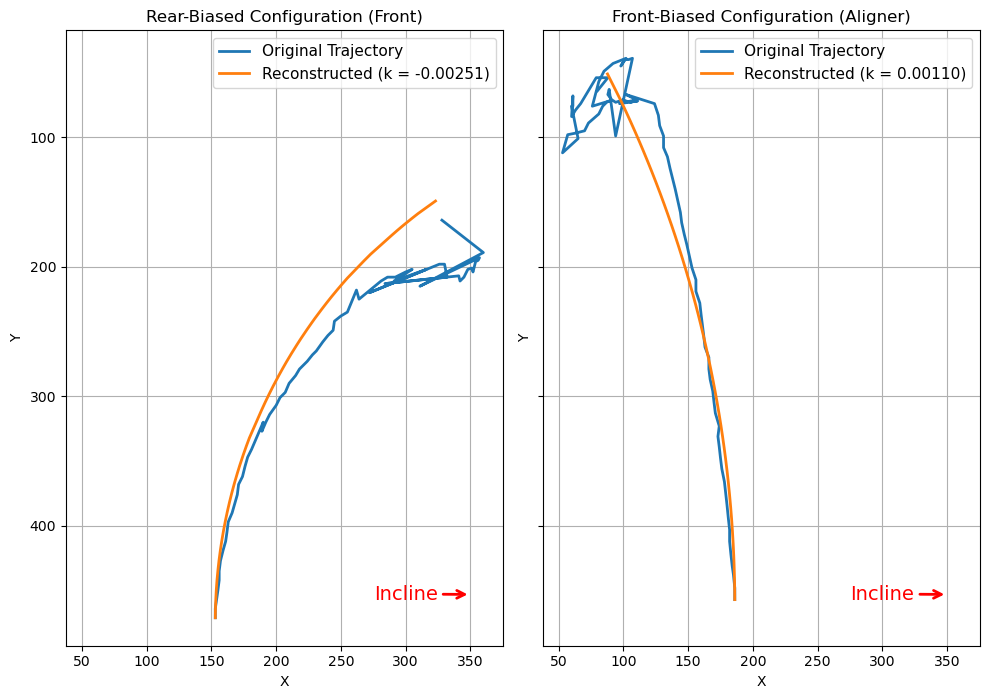

In [3]:
file1 = "../data/trajectories/first_trial_fronter.csv"
file2 = "../data/trajectories/first_trial_aligner.csv"

x1, y1, rx1, ry1, k1 = process_trajectory(file1)
x2, y2, rx2, ry2, k2 = process_trajectory(file2)

fig, axes = plt.subplots(1, 2, figsize=(10, 7), sharex=True, sharey=True)

# fronter
axes[0].plot(x1, y1, label="Original Trajectory", linewidth=2)
axes[0].plot(rx1[:47], ry1[:47], label=f"Reconstructed (k = {k1:.5f})", linewidth=2)
axes[0].set_title("Rear-Biased Configuration (Front)",fontsize=12)
axes[0].set_aspect('equal')
axes[0].invert_yaxis()
axes[0].legend(fontsize=11)
axes[0].set_xlabel("X")
axes[0].set_ylabel("Y")
axes[0].grid(True)
axes[0].annotate("Incline", xy=(350, 453), xytext=(300, 460),
                arrowprops=dict(arrowstyle="->", color="red", lw=2),
                fontsize=14, color="red", ha="center", va="bottom")


# aligner
axes[1].plot(x2, y2, label="Original Trajectory", linewidth=2)
axes[1].plot(rx2[:47], ry2[:47], label=f"Reconstructed (k = {k2:.5f})", linewidth=2)
axes[1].set_title("Front-Biased Configuration (Aligner)",fontsize=12)
axes[1].set_aspect('equal')
# axes[1].invert_yaxis()
axes[1].legend(fontsize=11)
axes[1].set_xlabel("X")
axes[1].set_ylabel("Y")
axes[1].grid(True)
axes[1].annotate("Incline", xy=(350, 453), xytext=(300, 460),
                arrowprops=dict(arrowstyle="->", color="red", lw=2),
                fontsize=14, color="red", ha="center", va="bottom")


# plt.suptitle("Comparison of Original and Reconstructed Trajectories", fontsize=14)
plt.tight_layout()
plt.show()